In [3]:
# Импорты и загрузка данных
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

if '../src' not in sys.path:
    sys.path.append('../src')
from database import load_worst_corrosion_by_component as load_data

DF_full = load_data()

In [5]:
# Целевая переменная
TARGET = 'corr_rate_worst_mm_per_year'

assert TARGET in DF_full.columns, f'В данных отсутствует {TARGET}'

print(f"Полный датасет: {len(DF_full):,} строк, {len(DF_full.columns)} колонок")
print('Колонки:', sorted(DF_full.columns.tolist()))

Полный датасет: 36,093 строк, 62 колонок
Колонки: ['ammonia_content', 'ammonium_chloride_content', 'avg_corr_rate_mm_per_year', 'chloride_aggressiveness', 'chlorine_content', 'co2_content', 'component', 'component_id', 'component_type', 'component_type_code', 'contour', 'corr_rate_worst_mm_per_year', 'corrosion_aggressiveness_index', 'corrosion_inhibitor_content', 'corrosion_protection_index', 'cross_section_area_mm2', 'curr_measurement_date', 'curr_thickness_avg_mm', 'curr_thickness_worst_mm', 'delta_years', 'effective_start_date', 'equipment', 'equipment_age_years', 'equipment_id', 'h2s_aggressiveness_index', 'h2s_content', 'h2s_water_ratio', 'hydrochloric_acid_content', 'initial_thickness', 'inner_diameter', 'installation', 'installation_id', 'material_code', 'material_code_id', 'material_grade', 'material_resistance_score', 'material_type', 'max_corr_rate_mm_per_year', 'min_corr_rate_mm_per_year', 'nominal_eff', 'nominal_thickness_mmc', 'num_points_in_section', 'num_sections', 'out

In [14]:
# Фильтр по установкам
# 54 - АВТ-6, 68 - АВТ-2, 53 - АВТ-1, 80 - АВТ-5, 4 - KK-2, 51 - КК
INSTALLATION_IDS = [4,51,80,53,68,54]

DF_loaded = DF_full[DF_full['installation_id'].isin(INSTALLATION_IDS)].copy()
DF_loaded = DF_loaded.sort_values('installation_id').reset_index(drop=True)
print(f"Отфильтровано (installation_id in {INSTALLATION_IDS}): {len(DF_loaded):,} строк")

# Только неотрицательная целевая переменная
#DF_loaded = DF_loaded[DF_loaded[TARGET] >= 0]
#print(f"После отбора строк с {TARGET} >= 0: {len(DF_loaded):,} строк")

# Вариант 2 (новый): занулить отрицательные значения целевой, строки остаются
#DF_loaded.loc[DF_loaded[TARGET] < 0, TARGET] = 0
#print(f"Отрицательные значения {TARGET} заменены на 0 ({(DF_loaded[TARGET] == 0).sum():,} нулей из {len(DF_loaded):,} строк)")

# Пустые в числовых признаках = 0; цель не заполняем
num_cols = [c for c in DF_loaded.select_dtypes(include=[np.number]).columns if c != TARGET]
DF_loaded[num_cols] = DF_loaded[num_cols].fillna(0)

print("Распределение по установкам:")
print(DF_loaded['installation_id'].value_counts().sort_index())

Отфильтровано (installation_id in [4, 51, 80, 53, 68, 54]): 36,093 строк
Распределение по установкам:
installation_id
4     6951
51    7529
53    3908
54    9929
68    3772
80    4004
Name: count, dtype: int64


In [27]:
# Признаки с наилучшей корреляцией с целью (по выводам correlation_analysis.ipynb)
# Рейтинг |r|: chlorine 0.231, equipment_age -0.224, nominal_thickness 0.149,
# cross_section 0.137, underdeposit -0.133, sodium_hydroxide 0.129, h2s_content 0.115
FEATURES = [
    'equipment_age_years',
    'cross_section_area_mm2',
    'nominal_thickness_mmc',
    'h2s_water_ratio'
]
FEATURES = [c for c in FEATURES if c in DF_loaded.columns]
print('Признаки для модели:', FEATURES)

Признаки для модели: ['equipment_age_years', 'cross_section_area_mm2', 'nominal_thickness_mmc', 'h2s_water_ratio']


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


def run_random_forest(df, features, target,
                      test_size=0.2, n_estimators=100,
                      max_depth=10, random_state=42):
    """
    Обучает RandomForest на df[features] -> df[target].
    Возвращает (model, metrics_df) — обученную модель и таблицу метрик.
    """
    features = [c for c in features if c in df.columns]
    df_reg = df[features + [target]].dropna(subset=[target]).copy()
    n_samples = len(df_reg)
    if n_samples < 10:
        raise ValueError(
            f"Слишком мало строк с заданной целью ({n_samples}). "
            f"Проверьте колонку {target}"
        )

    X = df_reg[features]
    y = df_reg[target]
    ts = test_size if n_samples >= 50 else max(0.15, 2 / n_samples)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=ts, random_state=random_state
    )

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=random_state
    )
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    r2_tr   = round(r2_score(y_train, y_pred_train), 4)
    mae_tr  = round(mean_absolute_error(y_train, y_pred_train), 6)
    rmse_tr = round(np.sqrt(mean_squared_error(y_train, y_pred_train)), 6)

    r2_te   = round(r2_score(y_test, y_pred_test), 4)
    mae_te  = round(mean_absolute_error(y_test, y_pred_test), 6)
    rmse_te = round(np.sqrt(mean_squared_error(y_test, y_pred_test)), 6)

    columns = pd.MultiIndex.from_tuples([
        ('Признаки', ''),
        ('Метрики на обучении:', 'R²'),
        ('Метрики на обучении:', 'MAE'),
        ('Метрики на обучении:', 'RMSE'),
        ('Метрики на тесте:', 'R²'),
        ('Метрики на тесте:', 'MAE'),
        ('Метрики на тесте:', 'RMSE'),
    ])

    metrics_df = pd.DataFrame(
        [[', '.join(features),
          r2_tr, mae_tr, rmse_tr,
          r2_te, mae_te, rmse_te]],
        columns=columns
    )
    metrics_df.index = ['']

    return model, metrics_df

Строк с заданной целью: 36,093
Обучающая выборка: 28,874 строк
Тестовая выборка:  7,219 строк


In [31]:
# Случайный лес (регрессия)
model, metrics_df = run_random_forest(DF_loaded, FEATURES, TARGET)
metrics_df

Признаки Метрики на обучении:  \
                                                                      R²   
  equipment_age_years, cross_section_area_mm2, n...               0.6082   

                     Метрики на тесте:                      
       MAE      RMSE                R²       MAE      RMSE  
  0.093697  0.292759            0.3246  0.107148  0.516464

                     признак  важность
       nominal_thickness_mmc  0.328079
      cross_section_area_mm2  0.296330
         equipment_age_years  0.151771
underdeposit_corrosion_index  0.097057
                 h2s_content  0.070882
             h2s_water_ratio  0.055358
    sodium_hydroxide_content  0.000521
            chlorine_content  0.000001


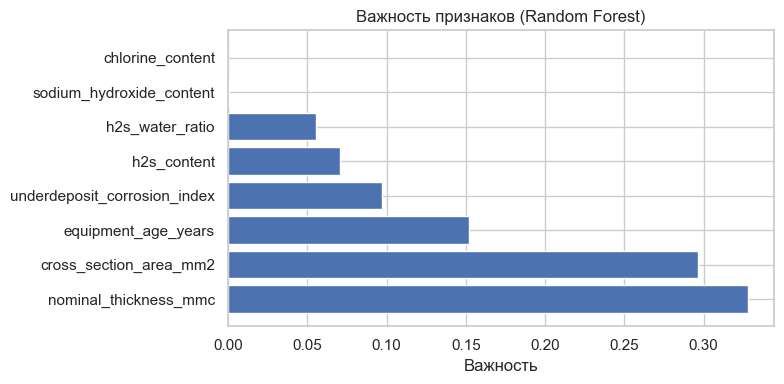

In [22]:
# Важность признаков (feature importance)
imp_df = pd.DataFrame({
    'признак': FEATURES,
    'важность': model.feature_importances_
}).sort_values('важность', ascending=False)
print(imp_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(imp_df['признак'], imp_df['важность'])
ax.set_xlabel('Важность')
ax.set_title('Важность признаков (Random Forest)')
plt.tight_layout()
plt.show()